# Metro Interstate Traffic Volume Data Visualization Final Project

**Course:** CIF444 Data Visualization  
**Student:** Burak Saltalı  
**Student ID:** 210129008  
**Dataset:** Metro Interstate Traffic Volume, UCI Machine Learning Repository  
**Dataset URL:** https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume  
**Random Seed:** 9008

## Task 1: Data Storytelling & Domain Knowledge

This project analyzes the **Metro Interstate Traffic Volume** dataset, which records hourly traffic volume on a metropolitan interstate corridor together with weather, holiday, and timestamp information. The original fetched dataset contains **48,204 rows and 9 columns** after combining UCI features and target values.

The real-world context is traffic monitoring and operational planning. Traffic volume is affected by commuting cycles, seasonal demand, weather disruptions, holidays, and incident-like anomalies. Understanding these patterns helps organizations move from reactive congestion response toward evidence-based planning.

The key stakeholders are **transportation planners**, **traffic engineers**, **city authorities**, **logistics managers**, and **emergency response planners**. Each group needs reliable traffic intelligence: planners need long-term demand patterns, engineers need operational bottleneck indicators, authorities need policy evidence, logistics teams need route and timing guidance, and emergency planners need awareness of periods when congestion may slow response.

Variable classification:

| Variable | Type | Reason |
|---|---|---|
| `traffic_volume` | Discrete numeric | Vehicle counts are integer observations over time. |
| `temp` | Continuous | Temperature can vary on a continuous scale. |
| `rain_1h` | Continuous | Rainfall amount over one hour. |
| `snow_1h` | Continuous | Snowfall amount over one hour. |
| `clouds_all` | Continuous / bounded numeric | Cloud coverage percentage from 0 to 100. |
| `holiday` | Nominal | Named holiday categories without numeric order. |
| `weather_main` | Nominal | General weather categories such as Clear, Clouds, Rain. |
| `weather_description` | Nominal | More specific weather descriptions. |
| `date_time` | Datetime | Timestamp of the traffic observation. |
| `hour`, `month`, `year` | Discrete temporal | Extracted calendar components. |
| `day_of_week` | Ordinal categorical | Weekday order can be defined from Monday to Sunday. |
| `is_weekend` | Nominal binary | Weekend vs weekday flag. |

## Task 2: Reproducible Data Access & Preprocessing

The dataset is fetched live from the UCI Machine Learning Repository using `ucimlrepo`. No local CSV file is used. The preprocessing strategy is conservative: inspect structure first, preserve original records, parse timestamps safely, create interpretable calendar features, and avoid dropping rows unless a later analysis explicitly requires a temporary filtered view.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

STUDENT_NAME = "Burak Saltalı"
STUDENT_ID = "210129008"
RANDOM_STATE = 9008

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)

In [2]:
def watermark_text(df):
    return f"{STUDENT_NAME} | ID: {STUDENT_ID} | Current Rows: {df.shape[0]}"


def add_dynamic_watermark(ax, df):
    """Add the required dynamic project watermark to a matplotlib axis."""
    ax.text(
        0.99,
        0.01,
        watermark_text(df),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="dimgray",
        alpha=0.85,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.65},
    )
    return ax


def set_title_with_watermark(ax, title, df):
    ax.set_title(f"{title}\n{watermark_text(df)}", fontsize=12, pad=12)
    return ax


def show_plot(fig):
    fig.tight_layout()
    plt.show()

In [3]:
metro_traffic = fetch_ucirepo(id=492)

X = metro_traffic.data.features.copy()
y = metro_traffic.data.targets.copy()

df = pd.concat([X, y], axis=1)
print(f"Fetched dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
df.head()

Fetched dataset shape: 48,204 rows and 9 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [5]:
df.describe(include="all")

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
count,61,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204,48204,48204.000000
unique,11,NaN,NaN,NaN,NaN,11,38,40575,NaN
top,Labor Day,NaN,NaN,NaN,NaN,Clouds,sky is clear,2013-04-18 22:00:00,NaN
freq,7,NaN,NaN,NaN,NaN,15164,11665,6,NaN
mean,NaN,281.205870,0.334264,0.000222,49.362231,NaN,NaN,NaN,3259.818355
std,NaN,13.338232,44.789133,0.008168,39.015750,NaN,NaN,NaN,1986.860670
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
25%,NaN,272.160000,0.000000,0.000000,1.000000,NaN,NaN,NaN,1193.000000
50%,NaN,282.450000,0.000000,0.000000,64.000000,NaN,NaN,NaN,3380.000000
75%,NaN,291.806000,0.000000,0.000000,90.000000,NaN,NaN,NaN,4933.000000


In [6]:
missing_table = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_table["missing_percent"] = (missing_table["missing_count"] / len(df) * 100).round(3)
missing_table.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
holiday,48143,99.873
temp,0,0.000
rain_1h,0,0.000
snow_1h,0,0.000
clouds_all,0,0.000
weather_main,0,0.000
weather_description,0,0.000
date_time,0,0.000
traffic_volume,0,0.000


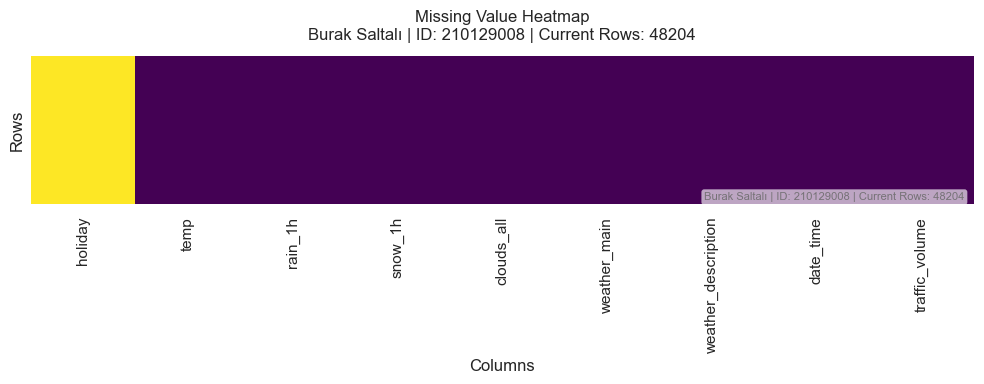

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
set_title_with_watermark(ax, "Missing Value Heatmap", df)
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
add_dynamic_watermark(ax, df)
show_plot(fig)

In [8]:
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = pd.Categorical(
    df["date_time"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
df["month"] = df["date_time"].dt.month
df["year"] = df["date_time"].dt.year
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

print(f"Final preprocessed shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
df.head()

Final preprocessed shape: 48,204 rows and 14 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,is_weekend
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,2012,False
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,2012,False
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2012,False
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,2012,False
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,2012,False


The missing value check shows whether any variables require imputation or filtering. The preprocessing keeps the dataset reproducible by deriving new fields directly from `date_time`, using deterministic code, and preserving the fetched rows. If future modeling requires complete numeric matrices, missing values should be handled in a task-specific copy rather than silently changing the main dataframe.

## Task 3: Outlier Analysis

Outliers are important in traffic data because they can represent incidents, unusual weather events, holidays, sensor problems, or genuinely extreme congestion. This section uses both univariate IQR rules and multivariate Isolation Forest anomaly detection.

In [9]:
continuous_features = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all"]
outlier_rows = []
outlier_masks = {}

for col in continuous_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_masks[col] = mask
    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,traffic_volume,1193.00,4933.000,3740.000,-4417.000,10543.000,0
1,temp,272.16,291.806,19.646,242.691,321.275,10
2,rain_1h,0.00,0.000,0.000,0.000,0.000,3467
3,snow_1h,0.00,0.000,0.000,0.000,0.000,63
4,clouds_all,1.00,90.000,89.000,-132.500,223.500,0


In [10]:
for _, row in outlier_summary.iterrows():
    print(
        f"{row['feature']}: Q1={row['Q1']:.3f}, Q3={row['Q3']:.3f}, "
        f"IQR={row['IQR']:.3f}, lower={row['lower_bound']:.3f}, "
        f"upper={row['upper_bound']:.3f}, outliers={int(row['outlier_count'])}"
    )

traffic_volume: Q1=1193.000, Q3=4933.000, IQR=3740.000, lower=-4417.000, upper=10543.000, outliers=0
temp: Q1=272.160, Q3=291.806, IQR=19.646, lower=242.691, upper=321.275, outliers=10
rain_1h: Q1=0.000, Q3=0.000, IQR=0.000, lower=0.000, upper=0.000, outliers=3467
snow_1h: Q1=0.000, Q3=0.000, IQR=0.000, lower=0.000, upper=0.000, outliers=63
clouds_all: Q1=1.000, Q3=90.000, IQR=89.000, lower=-132.500, upper=223.500, outliers=0


In [11]:
iqr_any_mask = pd.Series(False, index=df.index)
for mask in outlier_masks.values():
    iqr_any_mask = iqr_any_mask | mask

df_iqr_clean = df.loc[~iqr_any_mask].copy()
print(f"Rows before IQR filtering: {df.shape[0]:,}")
print(f"Rows after removing rows flagged by any key-feature IQR rule: {df_iqr_clean.shape[0]:,}")

Rows before IQR filtering: 48,204
Rows after removing rows flagged by any key-feature IQR rule: 44,668


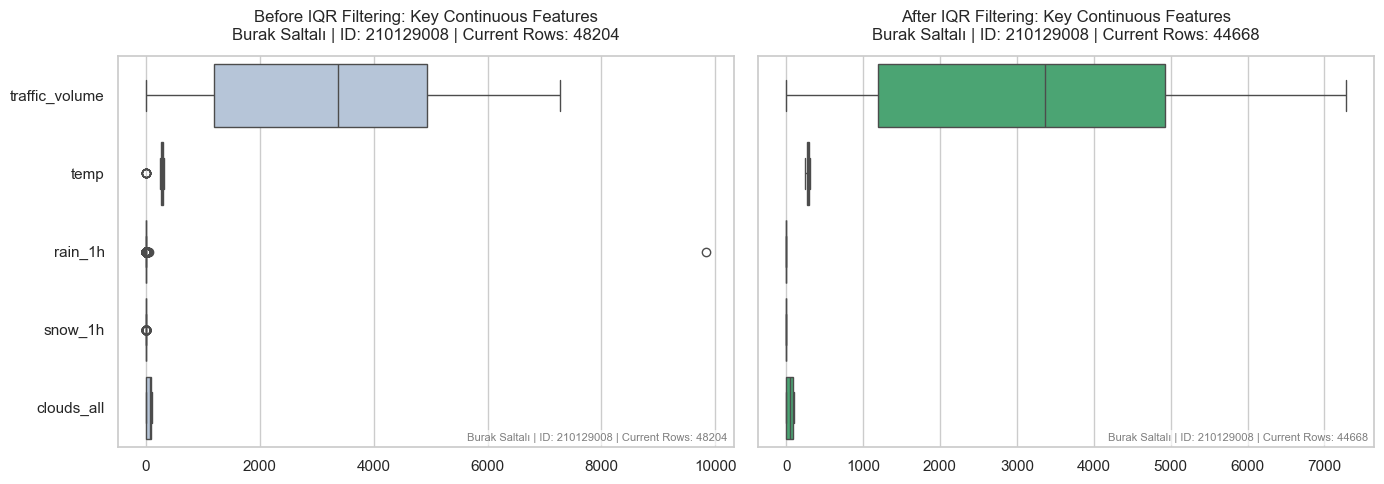

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.boxplot(data=df[continuous_features], orient="h", ax=axes[0], color="lightsteelblue")
set_title_with_watermark(axes[0], "Before IQR Filtering: Key Continuous Features", df)
add_dynamic_watermark(axes[0], df)

sns.boxplot(data=df_iqr_clean[continuous_features], orient="h", ax=axes[1], color="mediumseagreen")
set_title_with_watermark(axes[1], "After IQR Filtering: Key Continuous Features", df_iqr_clean)
add_dynamic_watermark(axes[1], df_iqr_clean)
show_plot(fig)

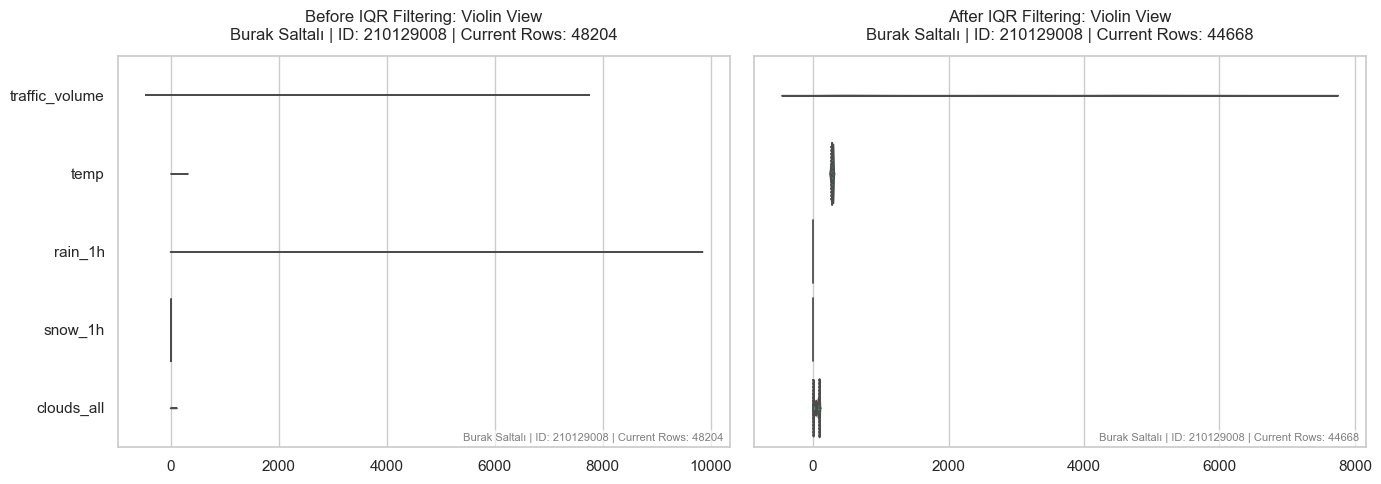

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.violinplot(data=df[continuous_features], orient="h", ax=axes[0], inner="quartile", color="lightsteelblue")
set_title_with_watermark(axes[0], "Before IQR Filtering: Violin View", df)
add_dynamic_watermark(axes[0], df)

sns.violinplot(data=df_iqr_clean[continuous_features], orient="h", ax=axes[1], inner="quartile", color="mediumseagreen")
set_title_with_watermark(axes[1], "After IQR Filtering: Violin View", df_iqr_clean)
add_dynamic_watermark(axes[1], df_iqr_clean)
show_plot(fig)

In [14]:
anomaly_features = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all", "hour", "month", "is_weekend"]
anomaly_df = df[anomaly_features].copy()
anomaly_df["is_weekend"] = anomaly_df["is_weekend"].astype(int)
anomaly_df = anomaly_df.fillna(anomaly_df.median(numeric_only=True))

scaler = StandardScaler()
anomaly_scaled = scaler.fit_transform(anomaly_df)

iso_model = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
df["anomaly_label"] = iso_model.fit_predict(anomaly_scaled)
df["anomaly_score"] = iso_model.decision_function(anomaly_scaled)
df["is_anomaly"] = df["anomaly_label"] == -1

top3_anomalies = df.nsmallest(3, "anomaly_score")
print("Top 3 most anomalous DataFrame index numbers:", top3_anomalies.index.tolist())
top3_anomalies[["date_time", "traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all", "weather_main", "anomaly_score"]]

Top 3 most anomalous DataFrame index numbers: [25168, 25169, 25170]


,date_time,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_main,anomaly_score
25168,2016-07-23 11:00:00,24,297.1,11.23,0.0,75,Rain,-0.133548
25169,2016-07-23 11:00:00,24,297.1,11.23,0.0,75,Thunderstorm,-0.133548
25170,2016-07-23 11:00:00,24,297.1,11.23,0.0,75,Mist,-0.133548


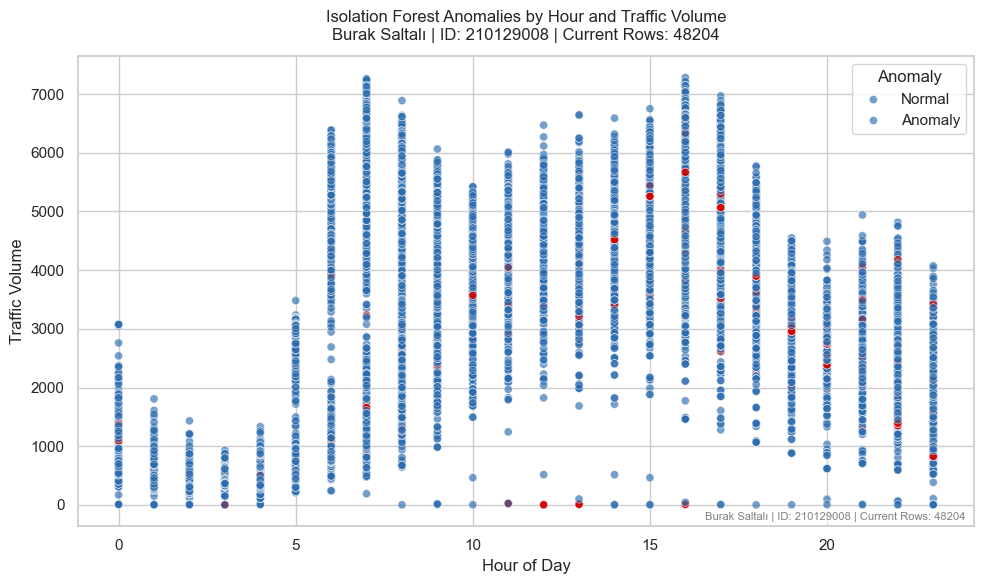

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="hour",
    y="traffic_volume",
    hue="is_anomaly",
    palette={False: "#2b6cb0", True: "#d00000"},
    alpha=0.65,
    s=35,
    ax=ax,
)
set_title_with_watermark(ax, "Isolation Forest Anomalies by Hour and Traffic Volume", df)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Traffic Volume")
ax.legend(title="Anomaly", labels=["Normal", "Anomaly"])
add_dynamic_watermark(ax, df)
show_plot(fig)

The IQR method identifies feature-specific extremes, while Isolation Forest detects unusual combinations across traffic, weather, and time. In operations, these anomalous records should not automatically be deleted; they may correspond to high-impact periods such as severe weather, holidays, or abnormal congestion that are important for planning.

## Task 4: Exploratory Visualization Engine

The following standalone visualizations use matplotlib and seaborn. Each plot includes the required dynamic watermark and is followed by a specific interpretation connected to traffic operations.

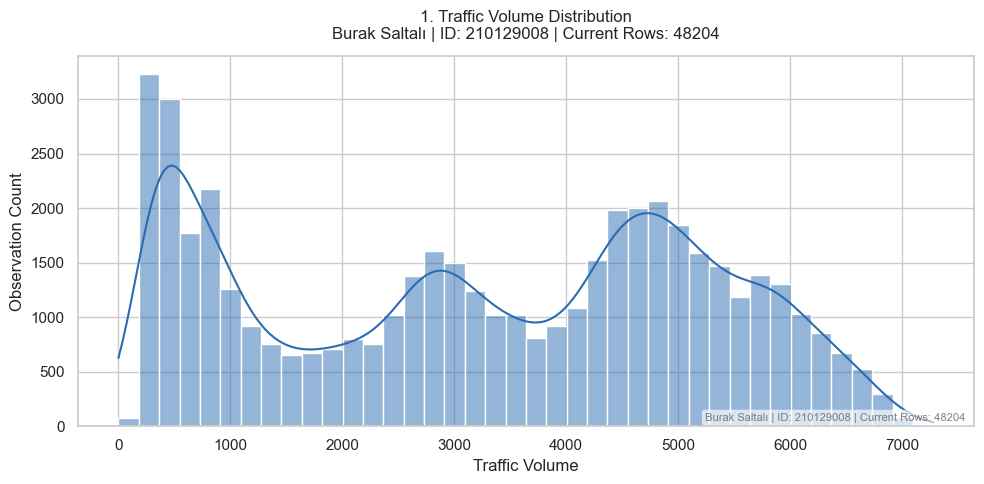

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="traffic_volume", bins=40, kde=True, ax=ax, color="#2b6cb0")
set_title_with_watermark(ax, "1. Traffic Volume Distribution", df)
ax.set_xlabel("Traffic Volume")
ax.set_ylabel("Observation Count")
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Traffic volume is not evenly distributed, which is typical for an interstate corridor with repeated low-demand and high-demand periods. The shape of the distribution helps traffic engineers understand whether congestion is an occasional peak problem or a recurring operating condition across many hours.

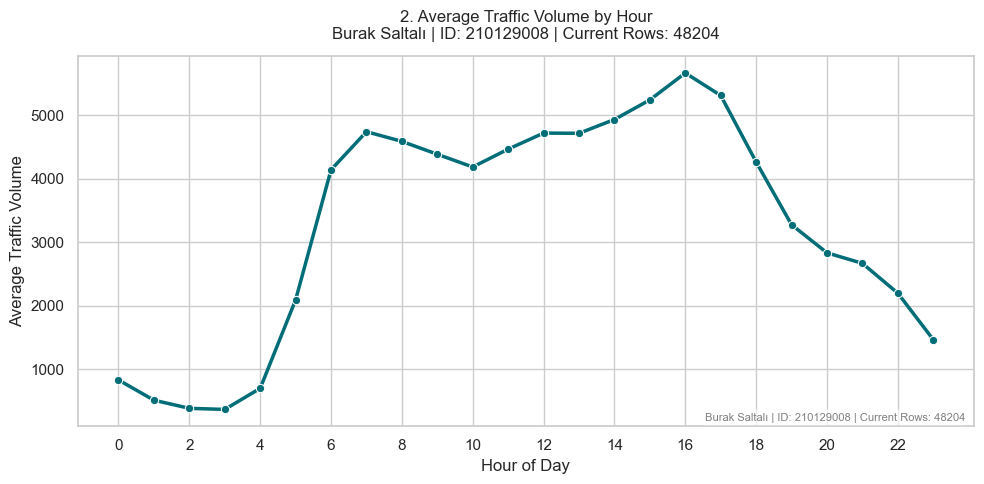

In [17]:
hourly_traffic = df.groupby("hour", as_index=False)["traffic_volume"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_traffic, x="hour", y="traffic_volume", marker="o", linewidth=2.5, ax=ax, color="#006d77")
set_title_with_watermark(ax, "2. Average Traffic Volume by Hour", df)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Traffic Volume")
ax.set_xticks(range(0, 24, 2))
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** The hourly profile shows the corridor's daily demand cycle. Peaks indicate when signal timing, ramp metering, incident response staffing, or traveler information systems should be most active to reduce delay.

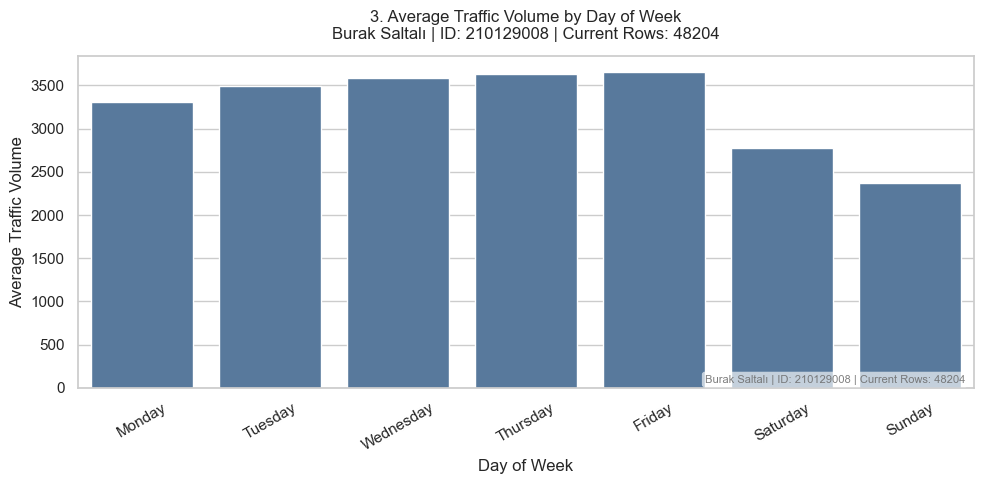

In [18]:
dow_traffic = df.groupby("day_of_week", observed=True, as_index=False)["traffic_volume"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=dow_traffic, x="day_of_week", y="traffic_volume", ax=ax, color="#4c78a8")
set_title_with_watermark(ax, "3. Average Traffic Volume by Day of Week", df)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Traffic Volume")
ax.tick_params(axis="x", rotation=30)
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Weekday and weekend differences reveal whether this corridor is mainly commuter-driven or also carries strong leisure and discretionary travel. This distinction matters for maintenance scheduling because lower-volume days create better work windows.

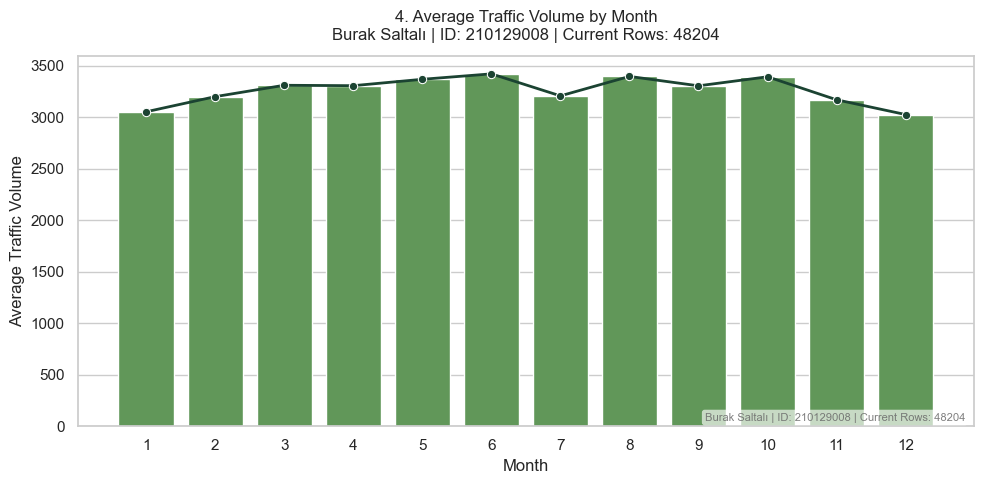

In [19]:
monthly_traffic = df.groupby("month", as_index=False)["traffic_volume"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_traffic, x="month", y="traffic_volume", ax=ax, color="#59a14f")
sns.lineplot(data=monthly_traffic, x=monthly_traffic["month"] - 1, y="traffic_volume", ax=ax, color="#1b4332", marker="o", linewidth=2)
set_title_with_watermark(ax, "4. Average Traffic Volume by Month", df)
ax.set_xlabel("Month")
ax.set_ylabel("Average Traffic Volume")
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Monthly variation indicates seasonal demand. If certain months show consistently heavier traffic, agencies can align construction restrictions, enforcement campaigns, or demand-management messaging with the seasonal operating risk.

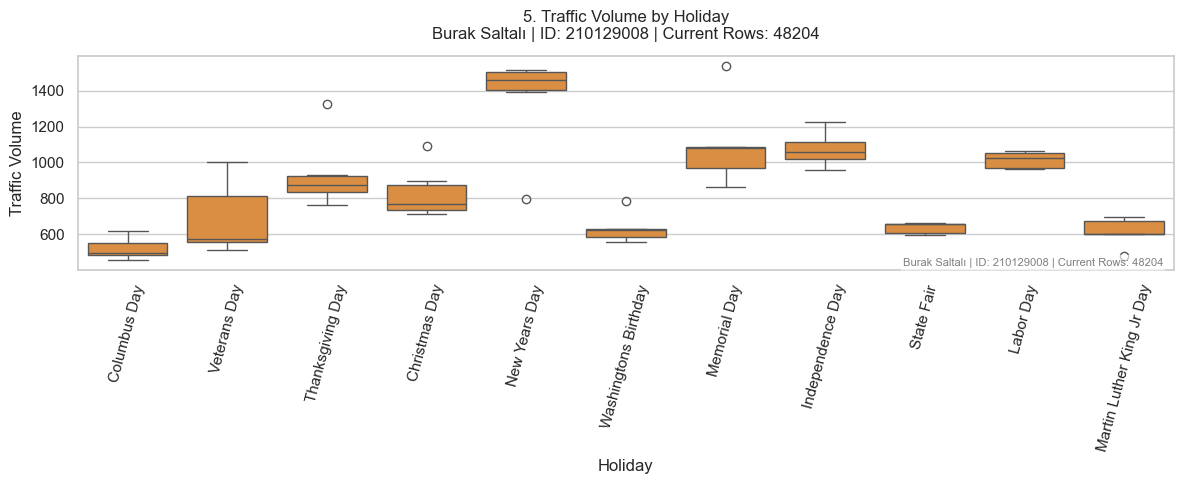

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="holiday", y="traffic_volume", ax=ax, color="#f28e2b")
set_title_with_watermark(ax, "5. Traffic Volume by Holiday", df)
ax.set_xlabel("Holiday")
ax.set_ylabel("Traffic Volume")
ax.tick_params(axis="x", rotation=75)
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Holiday categories help separate normal weekday demand from special-event or reduced-commute patterns. Transportation planners can use this view to avoid treating holiday traffic as ordinary weekday behavior in forecasting or staffing plans.

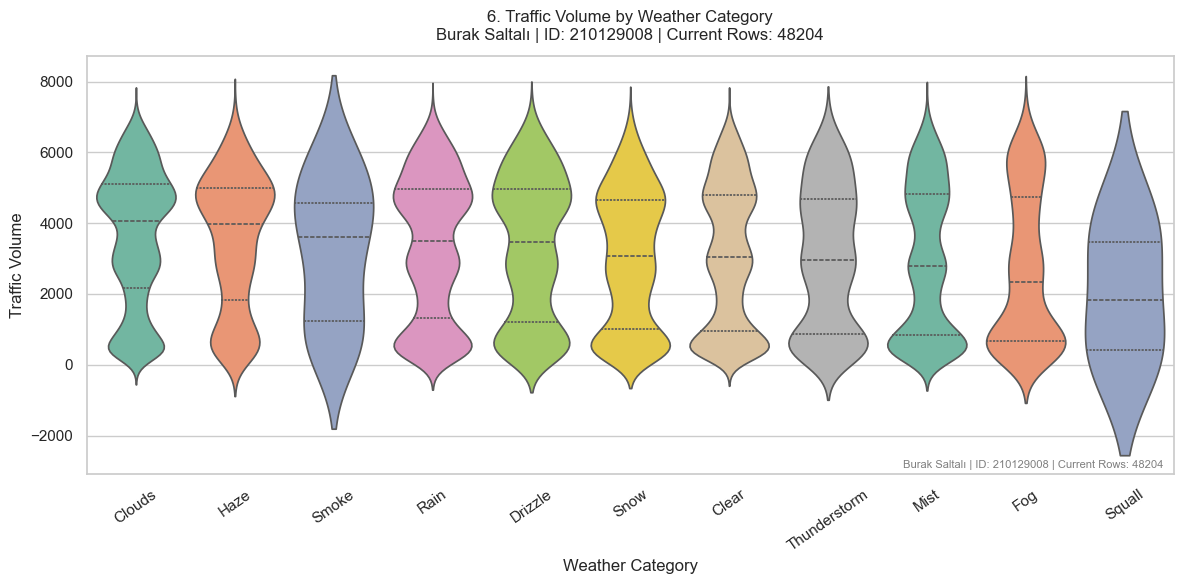

In [21]:
weather_order = df.groupby("weather_main")["traffic_volume"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x="weather_main", y="traffic_volume", order=weather_order, inner="quartile", ax=ax, palette="Set2")
set_title_with_watermark(ax, "6. Traffic Volume by Weather Category", df)
ax.set_xlabel("Weather Category")
ax.set_ylabel("Traffic Volume")
ax.tick_params(axis="x", rotation=35)
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Weather categories show how traffic volume varies under different operating conditions. Wide violins indicate that weather alone does not determine volume; time of day and season likely interact with weather to create the observed spread.

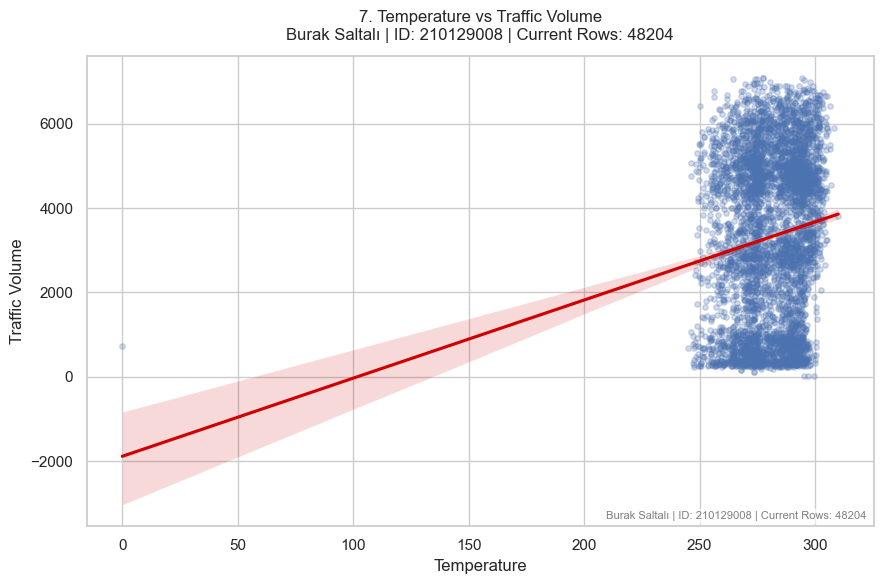

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE), x="temp", y="traffic_volume", scatter_kws={"alpha": 0.25, "s": 15}, line_kws={"color": "#d00000"}, ax=ax)
set_title_with_watermark(ax, "7. Temperature vs Traffic Volume", df)
ax.set_xlabel("Temperature")
ax.set_ylabel("Traffic Volume")
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** The regression plot tests whether temperature has a visible relationship with traffic demand. A weak slope would suggest that temperature is less important than commuting cycles, while a stronger pattern would support including temperature in operational forecasting models.

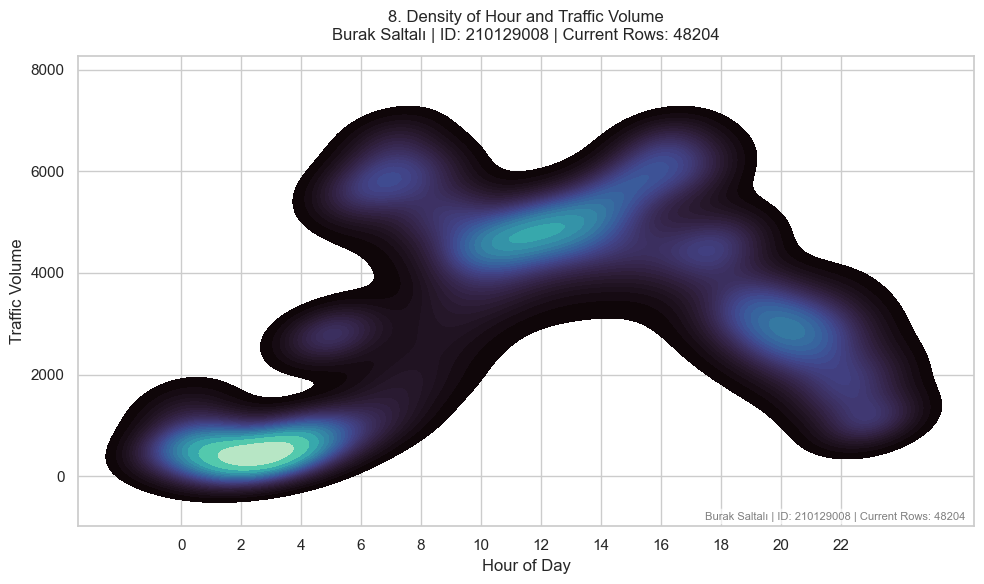

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x="hour", y="traffic_volume", fill=True, cmap="mako", thresh=0.03, levels=30, ax=ax)
set_title_with_watermark(ax, "8. Density of Hour and Traffic Volume", df)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Traffic Volume")
ax.set_xticks(range(0, 24, 2))
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** The density view identifies the most common combinations of hour and traffic level. Dense bands at certain hours show predictable operating regimes that are useful for baseline performance monitoring and anomaly detection.

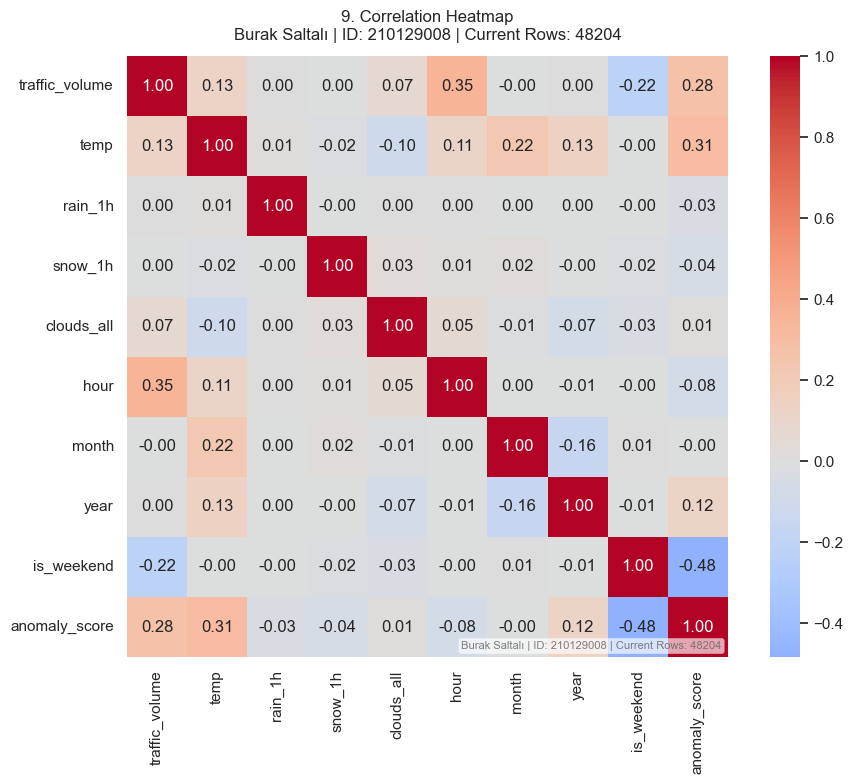

In [24]:
corr_cols = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all", "hour", "month", "year", "is_weekend", "anomaly_score"]
corr_df = df[corr_cols].copy()
corr_df["is_weekend"] = corr_df["is_weekend"].astype(int)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
set_title_with_watermark(ax, "9. Correlation Heatmap", df)
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** Correlation highlights which numeric variables move together linearly. Traffic operations teams should treat these as directional screening results rather than causal claims, especially because time-based cycles can mask or amplify weather relationships.

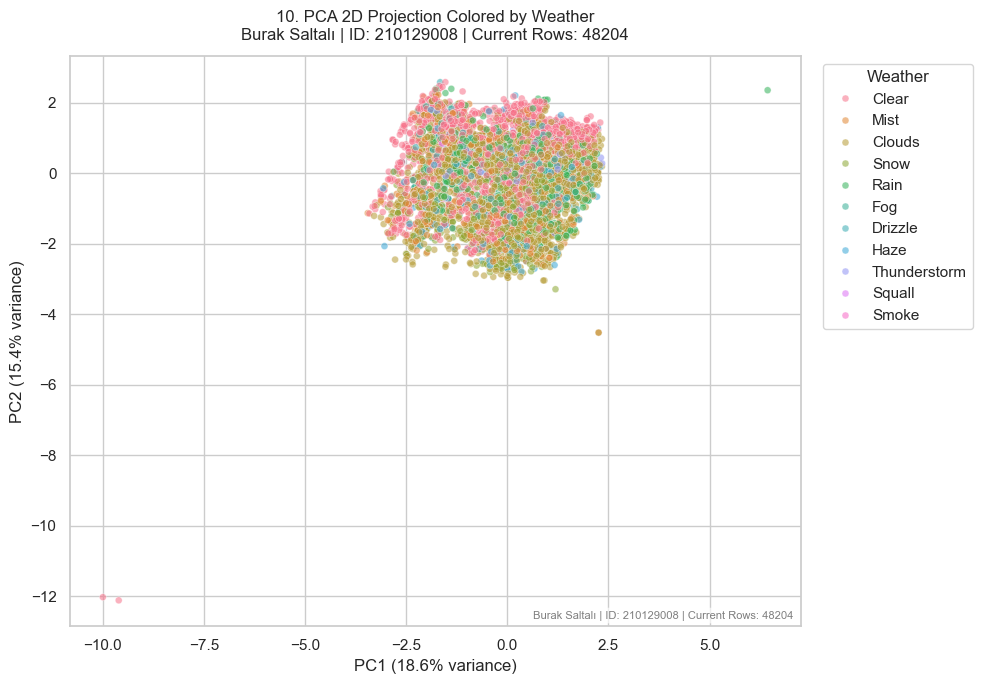

In [25]:
pca_features = ["traffic_volume", "temp", "rain_1h", "snow_1h", "clouds_all", "hour", "month", "is_weekend"]
pca_df = df[pca_features].copy()
pca_df["is_weekend"] = pca_df["is_weekend"].astype(int)
pca_df = pca_df.fillna(pca_df.median(numeric_only=True))
pca_scaled = StandardScaler().fit_transform(pca_df)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_values = pca.fit_transform(pca_scaled)
plot_pca = pd.DataFrame({"PC1": pca_values[:, 0], "PC2": pca_values[:, 1], "weather_main": df["weather_main"], "is_anomaly": df["is_anomaly"]})

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_pca.sample(min(8000, len(plot_pca)), random_state=RANDOM_STATE), x="PC1", y="PC2", hue="weather_main", alpha=0.55, s=25, ax=ax)
set_title_with_watermark(ax, "10. PCA 2D Projection Colored by Weather", df)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(title="Weather", bbox_to_anchor=(1.02, 1), loc="upper left")
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** PCA compresses multiple numeric traffic and weather variables into two dimensions. Clusters or separations by weather category suggest whether certain weather conditions produce distinct operational profiles that deserve separate monitoring thresholds.

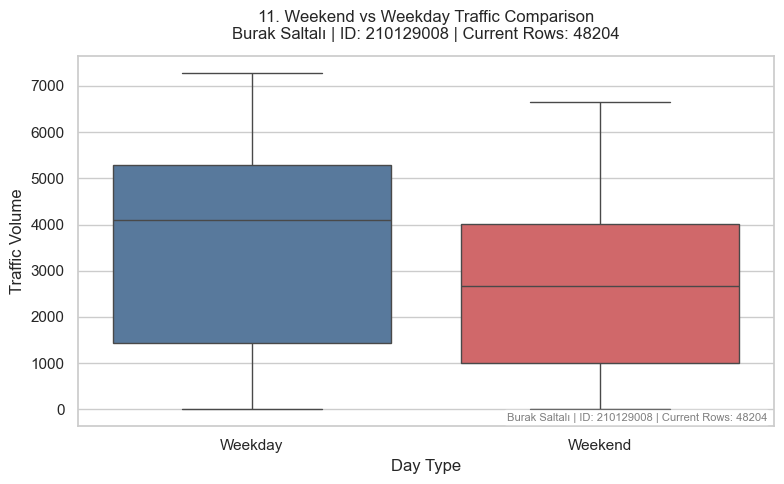

In [26]:
weekend_plot_df = df.copy()
weekend_plot_df["day_type"] = np.where(weekend_plot_df["is_weekend"], "Weekend", "Weekday")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=weekend_plot_df,
    x="day_type",
    y="traffic_volume",
    order=["Weekday", "Weekend"],
    ax=ax,
    palette={"Weekday": "#4c78a8", "Weekend": "#e15759"},
)
set_title_with_watermark(ax, "11. Weekend vs Weekday Traffic Comparison", df)
ax.set_xlabel("Day Type")
ax.set_ylabel("Traffic Volume")
add_dynamic_watermark(ax, df)
show_plot(fig)

**Interpretation:** The weekend comparison gives a direct view of commuter versus non-commuter demand. If weekday volumes are substantially higher, agencies can prioritize weekday peak management and reserve disruptive work for lower-demand weekend windows.

## Task 5: Executive Summary & Strategic Insights

1. **Prioritize peak-hour operations.** The hourly traffic pattern identifies predictable high-demand periods, so staffing, ramp control, incident response, and traveler messaging should be concentrated around those hours.

2. **Use weekday/weekend segmentation in planning.** Weekend and weekday traffic behave differently, so performance dashboards and forecasts should not use a single average baseline for all days.

3. **Treat holidays as special operating regimes.** Holiday traffic can differ from normal weekday demand, making holiday-aware forecasting important for scheduling maintenance, enforcement, and public communication.

4. **Monitor weather-sensitive demand separately.** Weather categories change the distribution of traffic volume, so severe or unusual weather should trigger separate operating thresholds rather than relying only on normal-day expectations.

5. **Use anomaly detection as an operational alert layer.** Isolation Forest highlights unusual combinations of time, weather, and volume. These records can support post-incident review, sensor QA checks, and early-warning dashboards.

6. **Build dashboards around interpretable calendar features.** Hour, day of week, month, and weekend status are simple to explain and operationally useful, making them strong candidates for executive reporting and engineering monitoring.

7. **Protect data quality while preserving rare events.** Extreme traffic observations should be reviewed rather than automatically removed, because rare high-impact conditions may be the most valuable cases for resilience planning.

In [27]:
print("Project completed successfully.")
print(f"Student name: {STUDENT_NAME}")
print(f"Student ID: {STUDENT_ID}")
print(f"Random state: {RANDOM_STATE}")
print(f"Final df shape: {df.shape}")

Project completed successfully.
Student name: Burak Saltalı
Student ID: 210129008
Random state: 9008
Final df shape: (48204, 17)
